# Project: Harry Potter characters

The ideas of our analysis is to discover/ do some interessting findings about the Harry Potter Universe and the relationships between the characters. We want to better understand the Wizarding World and see if some intuations are confirmes by a graph analysis. 
The main questions we want to awnser are:
* Do the number of citation in the books of each character really reflects its centrality in the universe.
* Are the Hogward houses a good way to split the characters?: do they form good communities? Does the vocabulary associated with the characters of each houses relfects the "values" of each houses? Which houses have the most positive vocabulary?
* Are Blood-Status a better way to split the Harry Potter characters? Do they form good communities?
* Most of the characters of Harry Potter universe can by said as "good" or "bad". If we spleet all the characters that way, who is the most "neutral" character (most balanced good/bad links ratio)? And can this measure be associated with any kind of centrality?

This notebook will be spet in 5 parts:

1. Download of the data and construction of the network
2. Basic Statistics about the Network
3. Number of citations
4. Hogward Houses text (TF_IDF and sentiment)
5. Communities (Hogward houses, Blood-Status or neither)
6. Most neutral character

## 1. Download of the data and construction of the network

* First we have looked for the most complete and large list of Harry Potter character we could find online (https://beyondhogwarts.com/harry-potter/books/character-list/)
* Then, manually we have constructed the txt file containing the list of all characters. We took all the chracters of this online list and checked what was the title of its corresponding fandom wiki page (https://harrypotter.fandom.com/wiki/{name}).
* In another notebook, we go through every names in this list and for each character we open the associated fandom wiki page's wikitext and create a local file to store the wikitext in a .txt file.
* To have all the wikitext accessible simply (without creating all the local files everytime), we pushed all the wikitext files as well as the hole list of characters name on our public github (https://github.com/EricBrevilliers/Harry_Potter_Graph)
* In the next cell, we go through the list of names on github to retrieve a list of character names.

In [6]:
# Go through the list of names on github to retrieve a list of character names
import urllib.request
import requests

# Read the file with the wikitext of the harry_Potter_characters list and extract the names
url_list = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/list_characters/harry_Potter_characters.txt"

response_list = requests.get(url_list)
names = [] # Initialize the list

if response_list.status_code == 200:
    content_list = response_list.text
    # We divide the string "content_list" in a list (one string/name per line)
    names = content_list.splitlines()
    
    # Ensure that there is no empty name
    names = [name for name in names if name.strip()]
    names = sorted(list(set(names)))
    print(f"Found {len(names)} names.")
else:
    print(f"Error retrieving file: {response_list.status_code}")

Found 412 names.


* In the next cell, we go through every characters previously added in the list and make each of them being a node. For all the characters we also search in the github the associated wikitext and use it to add a ***word_count* attribute** to each node and to add the edges.

In [2]:
# Go through every wikitext we have already saved in our github and construct the graph

import requests
import networkx as nx
import re

HpGraph = nx.DiGraph()
name_set = set(names)
names_clean = [name.replace('_', ' ').replace('%27', "'") for name in names] # clean more lisible names
names_url   = [name.replace('%27', '%2527') for name in names] # repcise name for the url

raw_to_clean = dict(zip(names, names_clean)) # Ex: raw_to_clean["Harry_Potter"] -> "Harry Potter"
raw_to_url   = dict(zip(names, names_url)) # Ex: raw_to_clean["Hermione_Granger%27s_mother"] -> "Hermione_Granger%2527s_mother"

print(f"Building graph from {len(names)} characters...")

for name in name_set:
    name_clean = raw_to_clean[name]
    name_url = raw_to_url[name]
    
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
    
        # Adds the node and the word_count attribute
        words = re.findall(r'\b\w+\b', content)
        word_count = len(words)
        HpGraph.add_node(name_clean, word_count=word_count)

        # Finds everything between [[ and the first |, #, or ]
        links = re.findall(r'\[\[([^\]\|#]+)', content)

        # Loop over all found links
        for link in links:
            # Filter to ignore 'File:', 'Category:', 'Image:', etc.
            if ':' in link:
                continue
            
            link_clean = link.strip().replace(' ', '_').replace("'", "%27")
            
            # We check if the normalized link is in our 'name_set'
            if link_clean in name_set:
                # Avoid a node pointing to itself
                if name != link_clean:
                    HpGraph.add_edge(name_clean, link)
    else:
        # It's normal to have some errors if a file was not
        # correctly saved or if the name has a typo
        print(f"[Warning] Failed to load: {name} (Status: {response.status_code})")

print(f"Graph construction complete. {HpGraph.number_of_nodes()} nodes added, {HpGraph.number_of_edges()} edges created.")

Building graph from 412 characters...
Graph construction complete. 412 nodes added, 6928 edges created.


* In the next cell we filter the newtowrk node to remove the isolated nodes

In [3]:
# Identify isolated nodes and remove them
nodes_to_remove = []
for node in HpGraph.nodes():
    if HpGraph.in_degree(node) == 0 and HpGraph.out_degree(node) == 0:
        nodes_to_remove.append(node)
        
HpGraph_noIsolatedNodes = HpGraph.copy()
HpGraph_noIsolatedNodes.remove_nodes_from(nodes_to_remove)
print(f"{len(nodes_to_remove)} isolated nodes deleted. {HpGraph_noIsolatedNodes.number_of_nodes()} nodes still in network.")

21 isolated nodes deleted. 391 nodes still in network.


* In the next cell we filter the network to only keep the larger connected component and we build the "twin" undirected graph.

In [4]:
# Finds the connected component and keeps the largest
weakly_connected_components = list(nx.weakly_connected_components(HpGraph))

if weakly_connected_components:
    largest_component = max(weakly_connected_components, key=len)
    HpGraph_connected = HpGraph.subgraph(largest_component).copy()
else:
    HpGraph_connected = HpGraph.copy()

print(f"Largest connected component contains {HpGraph_connected.number_of_nodes()} nodes")

HpGraph_undir = HpGraph_connected.to_undirected()

Largest connected component contains 387 nodes


## 2. Basic Statistics about the Network

### 2.1 First network information

#### 2.1.1 Basic Network information

In this section, we compute the most fundamental characteristics of the graph, including:
- The total number of nodes (characters)  
- The total number of edges (links between characters)  
- The density of the directed network

These metrics provide a first overview of how connected the Harry Potter character graph is.

In [10]:
# Basic Network Statistics: nodes, edges, density

# Get the number of nodes and edges
num_nodes = HpGraph_connected.number_of_nodes()
num_edges = HpGraph_connected.number_of_edges()

print("--- Basic Network Stats ---")
print(f"Nodes (Characters): {num_nodes}")
print(f"Edges (Links): {num_edges}")

# Density of a directed graph: edges / (N*(N-1))
# Calculate density, rounding to 4 decimals
if num_nodes > 1:
    max_possible_edges = num_nodes * (num_nodes - 1)
    density = num_edges / max_possible_edges
    print(f"Density: {density:.4f}")
else:
    print("Density: N/A")


--- Basic Network Stats ---
Nodes (Characters): 387
Edges (Links): 6924
Density: 0.0464


#### 2.1.2 Degree Statistic

To gain a deeper understanding of the structure of the Harry Potter character graph, we now compute:

- The **average in-degree** (how many characters link *to* a character)  
- The **average out-degree** (how many characters a character links *to*)  
- The **maximum in-degree**, and which character(s) receive the most links  
- The **maximum out-degree**, and which character(s) create the most links  

These metrics highlight the most central and influential characters in the network based on direct hyperlink connections.

In [11]:
#Compute in-degree and out-degree statistics

# Get dictionaries of degrees {node: degree}
in_degrees_dict = dict(HpGraph_connected.in_degree())
out_degrees_dict = dict(HpGraph_connected.out_degree())

# Calculate averages
avg_in = sum(in_degrees_dict.values()) / num_nodes
avg_out = sum(out_degrees_dict.values()) / num_nodes  # Note: avg_in and avg_out must be equal

# Find max values
max_in = max(in_degrees_dict.values())
max_out = max(out_degrees_dict.values())

# Find the characters with those max values
max_in_nodes = [node for node, deg in in_degrees_dict.items() if deg == max_in]
max_out_nodes = [node for node, deg in out_degrees_dict.items() if deg == max_out]

print(f"--- Degree Statistics ---")
print(f"Average in-degree: {avg_in:.4f}")
print(f"Average out-degree: {avg_out:.4f}")

print(f"\nMaximum in-degree: {max_in}")
print(f"Character(s) with maximum in-degree:")
for node in max_in_nodes:
    print(f"  - {node}")

print(f"\nMaximum out-degree: {max_out}")
print(f"Character(s) with maximum out-degree:")
for node in max_out_nodes:
    print(f"  - {node}")

--- Degree Statistics ---
Average in-degree: 17.8915
Average out-degree: 17.8915

Maximum in-degree: 280
Character(s) with maximum in-degree:
  - Harry Potter

Maximum out-degree: 168
Character(s) with maximum out-degree:
  - Harry Potter


The average in-degree and out-degree are both 17.8915, meaning a typical character page links to (or is linked by) about 18 other characters. This equality is expected in a directed graph.

Unsurprisingly, the character with the highest in-degree (280 links received) and the highest out-degree (168 links made) is **Harry Potter**, confirming his central role. His page is the most referenced, and it also links out to the widest range of other characters, making him the most structurally central node in the network.

#### 2.1.3 Degree Distributions

In the next cell we plot the distributions of in-degrees and out-degrees to understand how common highly connected characters are.  
These plots help reveal whether the network has a heavy-tailed structure (a few very connected characters and many with few links), which is typical for real-world hyperlink networks.

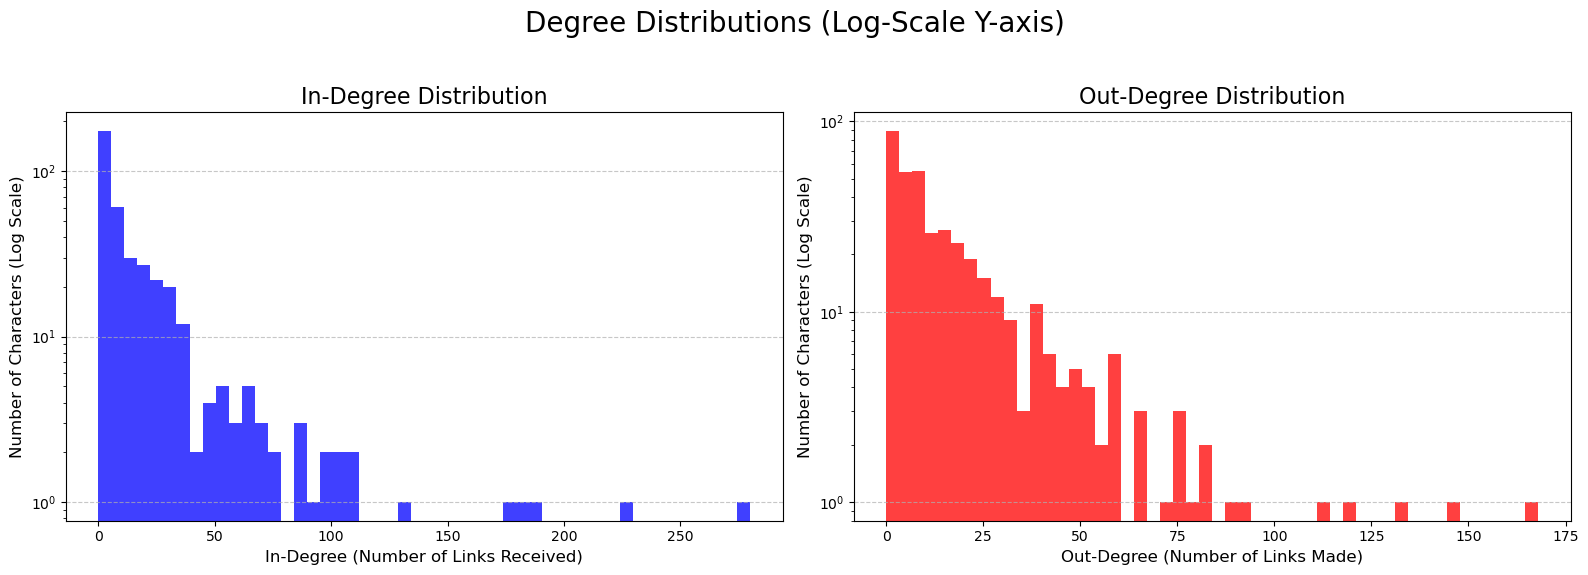

In [12]:
import matplotlib.pyplot as plt

# We already have the degree dictionaries from the previous cells
# in_degrees_dict = dict(HpGraph_connected.in_degree())
# out_degrees_dict = dict(HpGraph_connected.out_degree())

# Get just the degree values for plotting
in_degree_values = list(in_degrees_dict.values())
out_degree_values = list(out_degrees_dict.values())

# Create a figure with two subplots, side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: In-Degree Distribution ---
ax1.hist(in_degree_values, bins=50, alpha=0.75, color='b')
ax1.set_title('In-Degree Distribution', fontsize=16)
ax1.set_xlabel('In-Degree (Number of Links Received)', fontsize=12)
ax1.set_ylabel('Number of Characters (Log Scale)', fontsize=12)
ax1.set_yscale('log') # Use log scale as requested
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Out-Degree Distribution ---
ax2.hist(out_degree_values, bins=50, alpha=0.75, color='r') 
ax2.set_title('Out-Degree Distribution', fontsize=16)
ax2.set_xlabel('Out-Degree (Number of Links Made)', fontsize=12)
ax2.set_ylabel('Number of Characters (Log Scale)', fontsize=12)
ax2.set_yscale('log') # Use log scale
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Degree Distributions (Log-Scale Y-axis)', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

These histograms show the in-degree (left, blue) and out-degree (right, orange) for our 387-node network. The y-axis is on a log scale to better visualize the long tail.

Both plots show a clear **heavy-tailed distribution**, which is typical for real-world networks. This confirms our earlier finding:
* A vast majority of characters have a very low degree (they are "peripheral" characters).
* A "long tail" of a few, highly-connected nodes (like Harry Potter, Dumbledore, etc.) have a very high degree

### 2.2 Total size of the data 

We use the `word_count` attribute stored on each node and the raw wikitext files to estimate how large our corpus is.

In [13]:
# Total number of words in all character pages in the largest connected component

# Extract the "word_count" attribute for nodes in HpGraph_connected
word_counts = nx.get_node_attributes(HpGraph_connected, "word_count")

total_words = sum(word_counts.values())

print(f"Total number of words in all character pages: {total_words:,d}")

Total number of words in all character pages: 1,592,520


We approximate the total size of all wikitext files by summing the number of bytes downloaded for each character in the largest connected component. We then convert this total to megabytes.

In [14]:
import requests

total_bytes = 0

print(f"Calculating total file size for {HpGraph_connected.number_of_nodes()} nodes...")

for name in HpGraph_connected.nodes():
    
    base_filename = name.replace(" ", "_").replace("'", "%27")
    
    url_filename = base_filename.replace('%27', '%2527')
    
    # This URL now correctly points to the file on GitHub
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{url_filename}.txt"
    
    try:
        response = requests.get(url)
        if response.status_code == 200:
            total_bytes += len(response.content)
    except requests.exceptions.RequestException as e:
        print(f"Warning: Could not fetch {name}")

# Convert bytes to megabytes (using the 1024*1024 )
total_mb = total_bytes / (1024 * 1024)

print(f"\n--- Total File Size (for {HpGraph_connected.number_of_nodes()} nodes) ---")
print(f"Total Bytes: {total_bytes:,d}")
# Format to 4 decimal
print(f"Total Megabytes (MB): {total_mb:.4f} MB")

Calculating total file size for 387 nodes...

--- Total File Size (for 387 nodes) ---
Total Bytes: 9,946,601
Total Megabytes (MB): 9.4858 MB


Our final dataset (the largest connected component of the network) contains:

- **Total text:** 1,592,520 words  
- **Total file size:** approximately 9.486 MB  
- **Number of characters (nodes):** 387  

This text corpus will be used in the remainder of our analysis, both for network–text comparisons and for extracting semantic information from character pages.

## 3. Number of citations

### Citations vs network centrality

So far, we have only looked at how characters are positioned inside the hyperlink network  
(degrees and connections). However, in the *Harry Potter* books, the “importance” of a character  
is often measured by **how many times they are mentioned**.

In this section, we compare **textual importance** (book citations) with **structural importance**  
in the network (degree, betweenness and eigenvector centrality).  
This allows us to evaluate whether “important in the story” also means  
“central in the Wizarding World network”.


In [15]:
import requests
import re

# URL of the file with character names and citation counts
url_citations = "https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/list_characters/characters_with_citation_counts.txt"
response_citations = requests.get(url_citations)

citation_raw = {}

if response_citations.status_code == 200:
    lines = response_citations.text.splitlines()

    for line in lines:
        line = line.strip()
        if not line:
            continue

        # Extract the last integer as the citation count
        match = re.search(r'(\d+)$', line)
        if not match:
            continue

        count = int(match.group(1))
        raw_name = line[:match.start()].strip()

        citation_raw[raw_name] = count
else:
    print(f"Error retrieving citation file: {response_citations.status_code}")

# Map raw names to clean names using the mapping built earlier
citation_clean = {}
for raw_name, count in citation_raw.items():
    if raw_name in raw_to_clean:
        clean_name = raw_to_clean[raw_name]
        citation_clean[clean_name] = count

# Keep only characters that are in the largest connected component
book_citations = {
    node: citation_clean.get(node, 0)
    for node in HpGraph_connected.nodes()
}

# Attach as a node attribute
nx.set_node_attributes(HpGraph_connected, book_citations, name="book_citations")

num_with_citations = sum(1 for v in book_citations.values() if v > 0)

print(f"Number of nodes in the largest component: {HpGraph_connected.number_of_nodes()}")
print(f"Nodes with non-zero citation information: {num_with_citations}")


Number of nodes in the largest component: 387
Nodes with non-zero citation information: 372


To compare book citations with network centrality, we now build a table containing:

- number of book citations  
- degree in the undirected network  
- betweenness centrality  
- eigenvector centrality  

This will allow us to compare narrative importance with structural importance.


In [16]:
import pandas as pd

# Degree in the undirected graph
degree_dict = dict(HpGraph_undir.degree(HpGraph_connected.nodes()))

# Betweenness centrality
betweenness_dict = nx.betweenness_centrality(HpGraph_undir, normalized=True)

# Eigenvector centrality
eigenvector_dict = nx.eigenvector_centrality(HpGraph_undir, max_iter=1000)

# Build a DataFrame combining all metrics
rows = []
for node in HpGraph_connected.nodes():
    rows.append({
        "character": node,
        "citations": book_citations.get(node, 0),
        "degree": degree_dict.get(node, 0),
        "betweenness": betweenness_dict.get(node, 0.0),
        "eigenvector": eigenvector_dict.get(node, 0.0),
    })

centrality_df = pd.DataFrame(rows)

# Keep only characters with at least one citation in the books
centrality_df_nonzero = centrality_df[centrality_df["citations"] > 0].copy()

print(f"Characters with centrality + citation info: {len(centrality_df_nonzero)}")
centrality_df_nonzero.head()


Characters with centrality + citation info: 372


,character,citations,degree,betweenness,eigenvector
0,Moran,2,7,0.024420,0.003824
1,Connolly,1,2,0.000000,0.000115
2,Barry Ryan,1,4,0.005344,0.006958
3,Troy,1,3,0.005181,0.000084
4,Mullet,3,2,0.005181,0.000065


We first inspect the most cited characters and see how central they are in the network.


In [17]:
top_cited = (
    centrality_df_nonzero
    .sort_values(by="citations", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_cited


,character,citations,degree,betweenness,eigenvector
0,Harry Potter,18956,285,0.290605,0.213481
1,Ronald Weasley,6464,195,0.067306,0.191444
2,Hermione Granger,5486,192,0.059702,0.188405
3,Albus Dumbledore,2421,201,0.089112,0.182850
4,Rubeus Hagrid,2024,115,0.015844,0.133919
5,Severus Snape,1956,150,0.030085,0.163445
6,Tom Riddle,1797,228,0.128302,0.195191
7,Sirius Black,1471,117,0.020903,0.138360
8,Draco Malfoy,1198,116,0.012276,0.142379
9,Fred Weasley,920,102,0.013339,0.131770


If book citations truly reflect how “central” a character is,  
we expect a **positive correlation** between:

- number of citations  
- degree in the network  

We visualize this relationship.


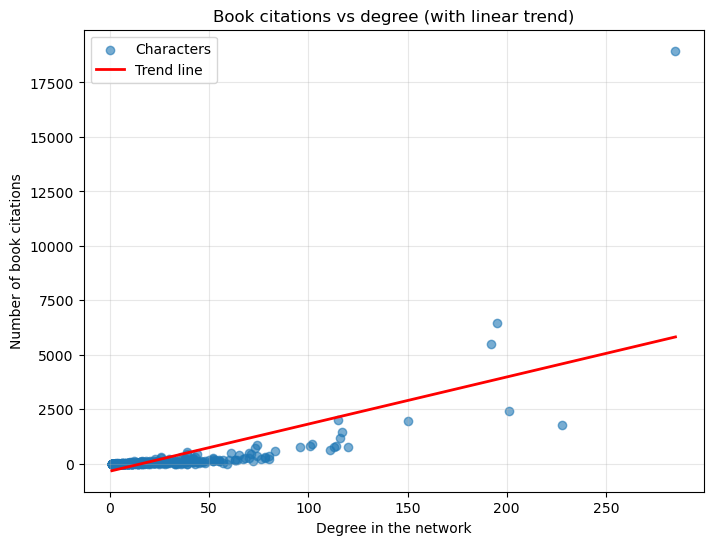

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x_degree = centrality_df_nonzero["degree"].values
y_citations = centrality_df_nonzero["citations"].values

# Fit linear regression: citations ≈ a * degree + b
slope, intercept = np.polyfit(x_degree, y_citations, 1)
x_line = np.linspace(min(x_degree), max(x_degree), 300)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 6))
plt.scatter(x_degree, y_citations, alpha=0.6, label="Characters")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Trend line")

plt.xlabel("Degree in the network")
plt.ylabel("Number of book citations")
plt.title("Book citations vs degree (with linear trend)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


The regression shows a clear positive trend: characters with many connections in the wiki  
are generally cited more often in the books.  
We now quantify the relationship using Pearson correlations.


In [19]:
# Compute Pearson correlations between citations and centralities
corr = centrality_df_nonzero[["citations", "degree", "betweenness", "eigenvector"]].corr(method="pearson")

# Extract the row corresponding to "citations"
corr_with_citations = corr.loc["citations", ["degree", "betweenness", "eigenvector"]]

# Format nicely
corr_table = corr_with_citations.to_frame(name="Pearson correlation with citations")
corr_table.index.name = "Centrality"

corr_table_rounded = corr_table.round(3)
corr_table_rounded


,Pearson correlation with citations
Centrality,
degree,0.671
betweenness,0.926
eigenvector,0.506


We observe strong positive correlations:  
characters frequently mentioned in the books also tend to be structurally central.  
However, the correlation is not perfect — this leaves room for **interesting outliers**.

We now identify characters whose textual and structural importance diverge the most.


In [20]:
# Compute z-scores for degree and citations
centrality_df_nonzero["z_degree"] = (
    (centrality_df_nonzero["degree"] - centrality_df_nonzero["degree"].mean())
    / centrality_df_nonzero["degree"].std()
)

centrality_df_nonzero["z_citations"] = (
    (centrality_df_nonzero["citations"] - centrality_df_nonzero["citations"].mean())
    / centrality_df_nonzero["citations"].std()
)

# Outliers = characters with strong mismatch
centrality_df_nonzero["z_diff"] = abs(
    centrality_df_nonzero["z_degree"] - centrality_df_nonzero["z_citations"]
)

# Show top 12 outliers
outliers = (
    centrality_df_nonzero.sort_values("z_diff", ascending=False)
    .head(12)
    .loc[:, ["character", "citations", "degree", "betweenness", "eigenvector", "z_diff"]]
)

outliers.reset_index(drop=True)


,character,citations,degree,betweenness,eigenvector,z_diff
0,Harry Potter,18956,285,0.290605,0.213481,9.424169
1,Tom Riddle,1797,228,0.128302,0.195191,4.501775
2,Albus Dumbledore,2421,201,0.089112,0.182850,3.143753
3,Ginevra Weasley,771,120,0.017677,0.144656,2.270784
4,Dolores Umbridge,637,111,0.016273,0.134917,2.128949
5,Severus Snape,1956,150,0.030085,0.163445,2.072507
6,Minerva McGonagall,770,113,0.014271,0.138149,2.066651
7,Neville Longbottom,810,114,0.013107,0.139916,2.059587
8,Draco Malfoy,1198,116,0.012276,0.142379,1.765523
9,George Weasley,821,101,0.015483,0.129425,1.668797


### Interpretation of outliers: narrative vs structural importance

The z-scores highlight characters whose **book presence (citations)** and  
**structural influence (degree)** disagree the most.

#### Much more central than their citations suggest
Characters such as **Harry Potter**, **Tom Riddle**, **Albus Dumbledore** act as huge structural hubs,  
connecting multiple communities (Hogwarts, Order, Ministry, Death Eaters).

#### Moderately cited but structurally key connectors
Examples include **Ginny Weasley**, **Snape**, **McGonagall**, **Neville**, **Umbridge**, **Draco** —  
all of them bridge several subgroups in the wiki graph.

#### Highly cited but more local in the network
**Fred and George Weasley** are often mentioned but remain mainly within  
the Weasley/Hogwarts community.

#### Low citation but surprisingly central
**Nymphadora Tonks**, despite a modest citation count, connects Aurors,  
the Order of the Phoenix, and the Lupin family.

### Conclusion
Book citations measure **narrative presence**,  
while network centrality measures **structural importance** in the Wizarding World.  
They correlate strongly, but the outliers reveal meaningful differences between  
“screen time” and “connectivity importance”.


## 4. Hogward houses text

## 5. Communities

### 5.1 Louvain communities on the hole network

In [165]:
def modularity(G, communities):
    # The number of link L in the graph
    L = len(G.edges())
    # the number of communities
    n_c = len(communities)
    # the number of links in each community L_c
    L_c = [0] * n_c
    # The sum of degrees of the nodes in each communities
    k_c = [0] * n_c
    
    for i in range(0,len(communities)):
        community = communities[i]

        # Compute k_c
        for node in community:
            k_c[i] += G.degree[node]

    # Compute L_c
    for i, community in enumerate(communities):
        for node1, node2 in G.edges():
            if node1 in community and node2 in community:
                L_c[i] += 1
    
    M = 0
    for c in range(n_c):
        M += L_c[c] / L - pow(k_c[c] / (2 * L), 2)
    return M

In [167]:
from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(HpGraph_undir, seed=1)

M_louvain = modularity(HpGraph_undir, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

0.2315089105010353
Nombre de communautés trouvées : 8


The communities are not good enougth (< 0.3), let's try to do it without the betweenness edges

### 5.2 Louvain without the betweenness hubs

In [43]:
# This cell is not useful, it does just print the top.20 betweenness nodes of the network

import networkx as nx

# Calculer la centralité d'intermédiarité pour tous les nœuds
betweenness_centrality = nx.betweenness_centrality(HpGraph_undir)

# Trier et afficher les 5 premiers nœuds
top_20_intermediaries = sorted(
    betweenness_centrality.items(), 
    key=lambda item: item[1], 
    reverse=True
)[:20]

print("--- Top 5 des Nœuds Intermédiaires (Betweenness Centrality) ---")
for node, score in top_20_intermediaries:
    # Le score est entre 0 et 1 (normalisé)
    print(f"{node}: {score:.4f}")

--- Top 5 des Nœuds Intermédiaires (Betweenness Centrality) ---
Harry Potter: 0.2906
Tom Riddle: 0.1283
Albus Dumbledore: 0.0891
Ronald Weasley: 0.0673
Hermione Granger: 0.0597
Arthur Weasley: 0.0311
Severus Snape: 0.0301
Moran: 0.0244
Sirius Black: 0.0209
Horace Slughorn: 0.0187
Ginevra Weasley: 0.0177
Dolores Umbridge: 0.0163
Reginald Cattermole: 0.0160
Rubeus Hagrid: 0.0158
George Weasley: 0.0155
Minerva McGonagall: 0.0143
Luna Lovegood: 0.0140
Fred Weasley: 0.0133
Neville Longbottom: 0.0131
Draco Malfoy: 0.0123


In [144]:
# --- CONFIGURATION FACILE ---
N_TOP_NODES = 15  # <--- MODIFIEZ CETTE VALEUR POUR RETIRER 2, 3, 4, 5, etc. nœuds.
# ---------------------------

# Assurez-vous que HpGraph_undir est bien défini.

# 1. Calculer la centralité d'intermédiarité
betweenness_centrality = nx.betweenness_centrality(HpGraph_undir)

# 2. Trier les nœuds par score décroissant et identifier le TOP N
# Triez les paires (nœud, score) en utilisant le score (l'élément[1])
sorted_nodes_by_betweenness = sorted(
    betweenness_centrality.items(), 
    key=lambda item: item[1], 
    reverse=True
)

# Extrayez le nom des N_TOP_NODES premiers nœuds
nodes_to_remove_list = [node for node, score in sorted_nodes_by_betweenness[:N_TOP_NODES]]

# 3. Créer une nouvelle version du graphe sans ces nœuds
HpGraph_debridged = HpGraph_undir.copy()
HpGraph_debridged.remove_nodes_from(nodes_to_remove_list)


# Finds the connected component and keeps the largest
weakly_connected_components = list(nx.connected_components(HpGraph_debridged))

if weakly_connected_components:
    largest_component = max(weakly_connected_components, key=len)
    HpGraph_debridged = HpGraph_debridged.subgraph(largest_component).copy()
else:
    HpGraph_debridged = HpGraph_debridged.copy()


# Affichage des informations sur le nouveau graphe
print(f"\n--- Après Suppression ---")
print(f"Graphe original (nœuds/arêtes) : {HpGraph_undir.number_of_nodes()} / {HpGraph_undir.number_of_edges()}")
print(f"Nouveau graphe 'HpGraph_debridged' (nœuds/arêtes) : {HpGraph_debridged.number_of_nodes()} / {HpGraph_debridged.number_of_edges()}")

# Le graphe HpGraph_debridged est maintenant prêt pour l'analyse


--- Après Suppression ---
Graphe original (nœuds/arêtes) : 387 / 4622
Nouveau graphe 'HpGraph_debridged' (nœuds/arêtes) : 343 / 2695


In [168]:
from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(HpGraph_debridged, seed=2)

M_louvain = modularity(HpGraph_debridged, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

print("\n--- Membres de chaque communauté ---")

# Utiliser enumerate pour numéroter les communautés
for i, community in enumerate(louvain_commu):
    # La variable 'community' est un ensemble (set) de nœuds
    # On peut trier les membres pour un affichage plus lisible
    members = sorted(list(community))
    
    # Affichage du résumé de la communauté
    print(f"\n🧠 Communauté {i+1} (Taille : {len(members)} membres) :")
    
    # Affichage des membres. Utiliser une jointure pour afficher sur une seule ligne.
    print(f"  {', '.join(members)}")

0.3379665497502763
Nombre de communautés trouvées : 7

--- Membres de chaque communauté ---

🧠 Communauté 1 (Taille : 76 membres) :
  Adrian Pucey, Alicia Spinnet, Amycus Carrow, Andrew Kirke, Angelina Johnson, Anthony Goldstein, Baruffio, Bertie Higgs, Blaise Zabini, Cassius Warrington, Cedric Diggory, Cho Chang, Colin Creevey, Cormac McLaggen, Crabbe, Daphne Greengrass, Dean Thomas, Demelza Robins, Dennis Creevey, Draco Malfoy, Edgecombe, Eloise Midgen, Ernest Macmillan, Fergus, Filius Flitwick, Firenze, Geoffrey Hooper, Gilderoy Lockhart, Gladys Gudgeon, Goyle, Graham Montague, Graham Pritchard, Gregory Goyle, Hannah Abbott, Harper, Jack Sloper, Jimmy Peakes, Justin Finch-Fletchley, Katie Bell, Lavender Brown, Leanne, Lee Jordan, Lucian Bole, Luna Lovegood, Marcus Belby, Marcus Flint, Marietta Edgecombe, Michael Corner, Miles Bletchley, Millicent Bulstrode, Mrs Norris, Neville Longbottom, Oliver Wood, Pansy Parkinson, Parvati Patil, Penelope Clearwater, Peregrine Derrick, Phyllida S

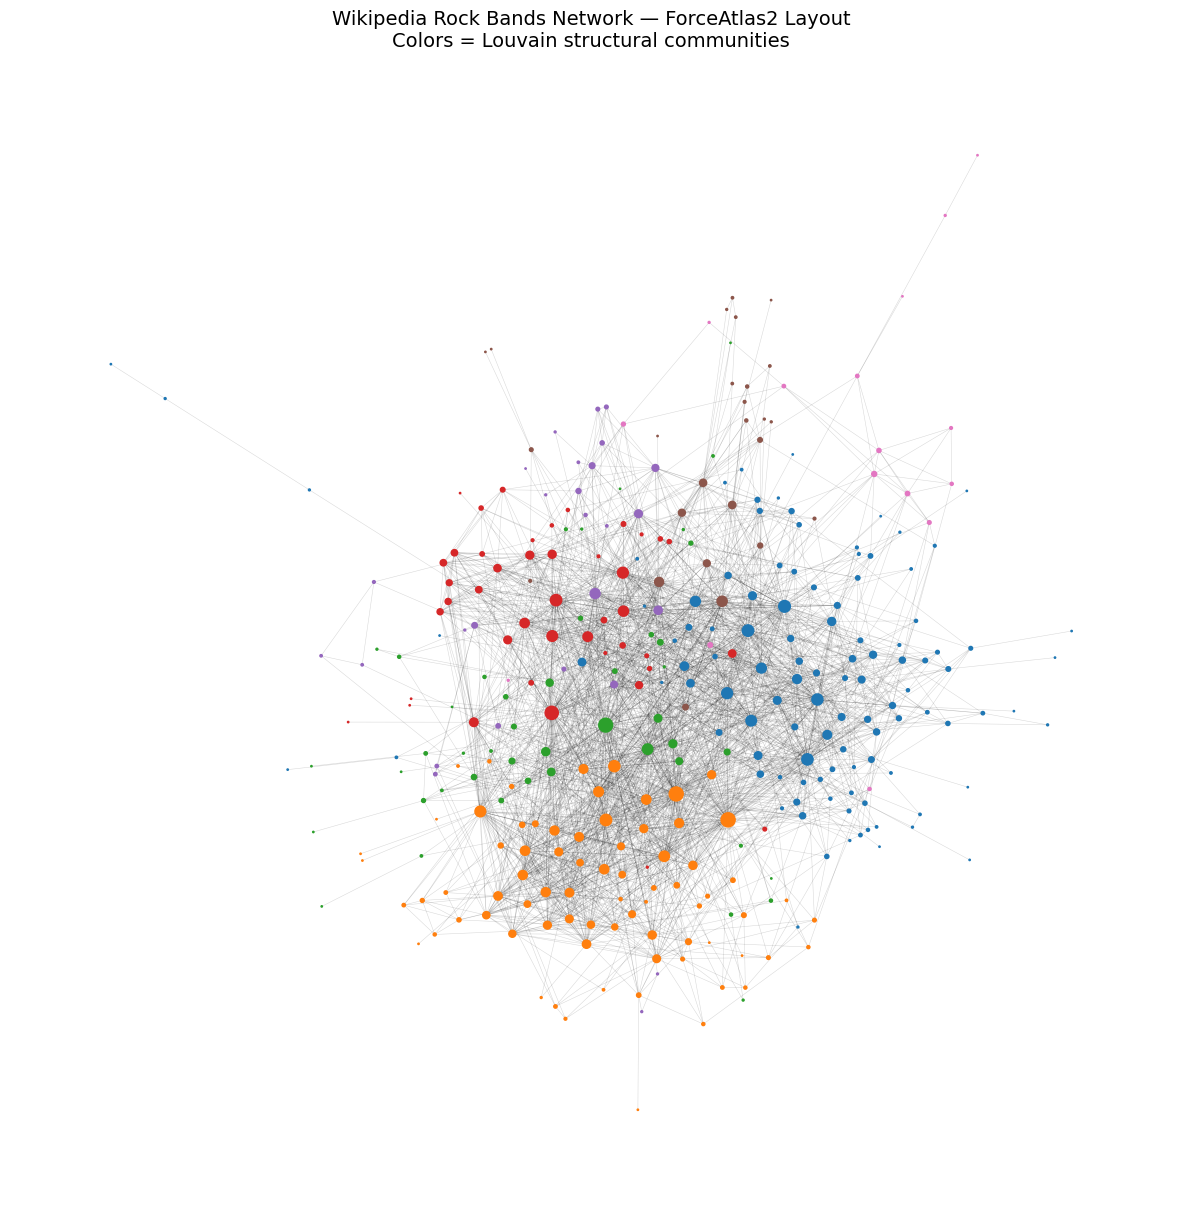

In [169]:
import matplotlib.pyplot as plt
import numpy as np

def color_choice(louvain_commu):
    # --- Sélection des plus grandes communautés ---
    sorted_comms = sorted(louvain_commu, key=len, reverse=True)
    top_k = 10  # on garde les 10 plus grandes
    top_comms = sorted_comms[:top_k]
    
    # Création d’un mapping node -> couleur
    color_map = {}
    colors = plt.cm.tab10.colors  # palette avec 10 couleurs distinctes
    for i, comm in enumerate(top_comms):
        for node in comm:
            color_map[node] = colors[i % len(colors)]
    
    # Les autres (petites communautés) seront gris clair
    for comm in sorted_comms[top_k:]:
        for node in comm:
            color_map[node] = (0.8, 0.8, 0.8)  # gris neutre

    return color_map

# --- Taille des nœuds proportionnelle au degré ---
node_sizes = [HpGraph_debridged.degree(n) for n in HpGraph_debridged.nodes()]

# --- Positionnement avec ForceAtlas2 ---
pos = nx.forceatlas2_layout(
    HpGraph_debridged,
    max_iter=300,
    scaling_ratio=1.0,
    gravity=1.0,
    jitter_tolerance=1.0
)

# --- Couleurs des nœuds ---
color_map = color_choice(louvain_commu)
node_colors = [color_map[n] for n in HpGraph_debridged.nodes()]

# --- Affichage ---
plt.figure(figsize=(15, 15))
nx.draw_networkx_edges(HpGraph_debridged, pos, alpha=0.15, width=0.4, edge_color="black")
nx.draw_networkx_nodes(
    HpGraph_debridged, pos,
    node_size=node_sizes,
    node_color=node_colors
)

plt.title("Wikipedia Rock Bands Network — ForceAtlas2 Layout\nColors = Louvain structural communities", fontsize=14)
plt.axis("off")
plt.show()

### 5.3 Houses as communities

#### 5.3.1 Finding the houses

##### 5.3.1.1 Total houses graph

First, we need to find the Hogward houses of each characters that belongs to one. To do so, we look at the wikipedia infobox of each character and at the "house" line.

In [154]:
import re
import requests

def get_full_infobox(text):
    """
    Gets the full content fo the infobox by dealing with the interlocking {{...{{...}}...}}
    """
    start_marker = "{{Individual infobox"
    start_index = text.find(start_marker)
    
    if start_index == -1:
        return None
    
    # We start counting after the opening marker
    current_index = start_index
    brace_count = 0
    found_first_open = False
    
    # We go through the text char by char
    # we look for the closing corresponding to the first {{
    for i in range(start_index, len(text)):
        # we look for both char at a time to find {{ or }}
        chunk = text[i:i+2]
        
        if chunk == '{{':
            brace_count += 1
            found_first_open = True
        elif chunk == '}}':
            brace_count -= 1
            
        # If we opened curly braces and returned to 0, that's the end of the infobox.
        if found_first_open and brace_count == 0:
            # We return the entire block (+2 to include the final }}
            return text[start_index:i+2]
            
    return None

def extract_house(file_content):
    """
    Extracts the house only if it is formatted as a wiki link [...]
    """
    
    infobox_content = get_full_infobox(file_content)
    
    if not infobox_content:
        return None

    house_match = re.search(
        r'\|\s*house\s*=\s*\[\[([^|\]]+)', 
        infobox_content, 
        re.IGNORECASE
    )
    
    if house_match:
        return house_match.group(1).strip()
    
    return None

In [155]:
characters_houses = dict()

for name in name_set:
    name_clean = raw_to_clean[name]
    name_url = raw_to_url[name]
    
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
        house = extract_house(content)
        
        if house:
            characters_houses[name_clean] = house

In [156]:
from collections import Counter

all_houses = list(characters_houses.values())

house_counts = Counter(all_houses)

print(f"\n--- Number of characters in each houses (Total: {len(characters_houses)}) ---")

for house, count in house_counts.most_common():
    print(f"{house:<15} : {count}")


--- Number of characters in each houses (Total: 151) ---
Gryffindor      : 54
Slytherin       : 48
Ravenclaw       : 27
Hufflepuff      : 22


As we can see, only 151 out of the 412 characters have a hogward house. Other peaples have none either because their are not well known enough and we don't know their house, because they are wizards that comes from other magic schools or they are not wizards (muggles, fantastic beast, animals, ...).

In this part, we will only keep the nodes that have a house (in ***HpHouseGraph***)

In [157]:
import networkx as nx

nodes_to_keep = list(characters_houses.keys())

# we create a new graph : HpHouseGraph that keeps only the nodes that belongs to a house.
HpHouseGraph = HpGraph_undir.subgraph(nodes_to_keep).copy()

# in this graph, the nodes have a new attribute: house
nx.set_node_attributes(HpHouseGraph, characters_houses, name="house")

print(f"Original Graph : {HpGraph_undir.number_of_nodes()} nodes, {HpGraph_undir.number_of_edges()} links.")
print(f"New Graph (House only) : {HpHouseGraph.number_of_nodes()} nodes, {HpHouseGraph.number_of_edges()} links.")

Original Graph : 387 nodes, 6924 links.
New Graph (House only) : 143 nodes, 2035 links.


##### 5.3.1.2 Houses graph without the betweenness hubs

In [152]:
N_TOP_NODES = 15

# 1. Calculer la centralité d'intermédiarité
betweenness_centrality = nx.betweenness_centrality(HpHouseGraph)

# 2. Trier les nœuds par score décroissant et identifier le TOP N
# Triez les paires (nœud, score) en utilisant le score (l'élément[1])
sorted_nodes_by_betweenness = sorted(
    betweenness_centrality.items(), 
    key=lambda item: item[1], 
    reverse=True
)

# Extrayez le nom des N_TOP_NODES premiers nœuds
nodes_to_remove_list = [node for node, score in sorted_nodes_by_betweenness[:N_TOP_NODES]]

# 3. Créer une nouvelle version du graphe sans ces nœuds
HpHouseGraph_debridged = HpHouseGraph.copy()
HpHouseGraph_debridged.remove_nodes_from(nodes_to_remove_list)


# Finds the connected component and keeps the largest
weakly_connected_components = list(nx.connected_components(HpHouseGraph_debridged))

if weakly_connected_components:
    largest_component = max(weakly_connected_components, key=len)
    HpGraph_debrHpHouseGraph_debridgedidged = HpHouseGraph_debridged.subgraph(largest_component).copy()
else:
    HpHouseGraph_debridged = HpHouseGraph_debridged.copy()


# Affichage des informations sur le nouveau graphe
print(f"\n--- Après Suppression ---")
print(f"Graphe original (nœuds/arêtes) : {HpHouseGraph.number_of_nodes()} / {HpHouseGraph.number_of_edges()}")
print(f"Nouveau graphe 'HpHouseGraph_debridged' (nœuds/arêtes) : {HpHouseGraph_debridged.number_of_nodes()} / {HpHouseGraph_debridged.number_of_edges()}")


--- Après Suppression ---
Graphe original (nœuds/arêtes) : 143 / 2035
Nouveau graphe 'HpHouseGraph_debridged' (nœuds/arêtes) : 128 / 921


#### 5.3.2 Houses as communities

In [163]:
# we need to construct the dictionary: house -> set(characters)
house_to_character = {}
for character in HpHouseGraph_debridged.nodes():
    house = characters_houses[character]

    if(house not in house_to_character.keys()):
        house_to_character[house] = set()

    house_to_character[house].add(character)

# Modularity for the house-communities
M = modularity(HpHouseGraph_debridged, list(house_to_character.values()))
print(M)

0.13061853883507163


In [164]:
# just in case it is useful, here is the Louvain algorithm with this newly filtred network (only hogwards student): it gives still good comminities
from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(HpHouseGraph_debridged, seed=6)

M_louvain = modularity(HpHouseGraph_debridged, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

0.3064583060710341
Nombre de communautés trouvées : 11


### 5.4 Blood-Status as communities

#### 5.4.1 Finding the Blood-Status

##### 5.3.1.1 Total blood-status graph

In [170]:
# Species
def extract_species(file_content):
    """
    Extracts the species only if it is formatted as a wiki link [...]
    """
    
    infobox_content = get_full_infobox(file_content)
    
    if not infobox_content:
        return None

    species_match = re.search(
        r'\|\s*species\s*=\s*\[\[([^|\]]+)', 
        infobox_content, 
        re.IGNORECASE
    )
    
    if species_match:
        return species_match.group(1).strip()
    
    return None


# Blood
def extract_blood(file_content):
    """
    Extracts the blood-status only if it is formatted as a wiki link [...]
    """
    
    infobox_content = get_full_infobox(file_content)
    
    if not infobox_content:
        return None

    blood_match = re.search(
        r'\|\s*blood\s*=\s*\[\[([^|\]]+)', 
        infobox_content, 
        re.IGNORECASE
    )
    
    if blood_match:
        return blood_match.group(1).strip()
    
    return None

In [171]:
# Species
characters_species = dict()

for name in name_set:
    name_clean = raw_to_clean[name]
    name_url = raw_to_url[name]
    
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
        species = extract_species(content)
        
        if species:
            characters_species[name_clean] = species

# Blood
characters_blood = dict()

for name in name_set:
    name_clean = raw_to_clean[name]
    name_url = raw_to_url[name]
    
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
        blood = extract_blood(content)
        
        if blood:
            characters_species[name_clean] = blood

## 6. Dark/Bright side centrality
Can we find out which characters have a central role linking both sides of the line defined by good and evil?

### 6.1 Creation of the evil/good side dictionnary

We will now manually create a dictionnary that maps most important and polarized characters with a label -1,1. The label -1 will be attributed if the character is evil and 1 otherwise. Few things to say:
* characters that were too central such as Harry, Hermione or even "the one who shall not be named" have been on purposely left out since the information gain is very low (everybody points at them).
* most characters have a small role or their position can't be summarized to a simple binary label, for this they won't be included either.


In [27]:
side = {
    "Severus Snape": 1,
    "Rubeus Hagrid": 1,
    "Minerva McGonagall": 1,
    "Draco Malfoy": -1,
    "Ginny Weasley": 1,
    "Arthur Weasley": 1,
    "Molly Weasley": 1,
    "Fred Weasley": 1,
    "George Weasley": 1,
    "Bill Weasley": 1,
    "Charlie Weasley": 1,
    "Filius Flitwick": 1,
    "Pomona Sprout": 1,
    "Sybill Trelawney": 1,
    "Horace Slughorn": 1,
    "Dolores Umbridge": -1,
    "Argus Filch": -1,
    "Poppy Pomfrey": 1,
    "Madam Hooch": 1,
    "Albus Dumbledore": 1,
    "Sirius Black": 1,
    "Remus Lupin": 1,
    "Nymphadora Tonks": 1,
    "Kingsley Shacklebolt": 1,
    "Alastor Moody": 1,
    "Dedalus Diggle": 1,
    "Hestia Jones": 1,
    "Emmeline Vance": 1,
    "Elphias Doge": 1,
    "Arabella Figg": 1,
    "Bellatrix Lestrange": -1,
    "Lucius Malfoy": -1,
    "Narcissa Malfoy": -1,
    "Peter Pettigrew": -1,
    "Bartemius Crouch Junior": -1,
    "Antonin Dolohov": -1,
    "Fenrir Greyback": -1,
    "Walden Macnair": -1,
    "Igor Karkaroff": -1,
    "Alecto Carrow": -1,
    "Amycus Carrow": -1,
    "Travers": -1,
    "Corban Yaxley" : -1,
    "Rabastan Lestrange": -1,
    "Augustus Rookwood": -1,
    "Nott": -1,
    "Evan Rosier": -1,
    "Selwyn": -1,
    "Neville Longbottom": 1,
    "Luna Lovegood": 1,
    "Cho Chang": 1,
    "Cedric Diggory": 1,
    "Dean Thomas": 1,
    "Seamus Finnigan": 1,
    "Colin Creevey": 1,
    "Lee Jordan": 1,
    "Angelina Johnson": 1,
    "Katie Bell": 1,
    "Oliver Wood": 1,
    "Dobby": 1,
    "Kreacher": -1,
    "Fawkes": 1,
    "Buckbeak": 1,
    "Hedwig": 1,
    "Fleur Delacour": 1,
    "Gabrielle Delacour": 1,
    "Aberforth Dumbledore": 1,
    "Gellert Grindelwald": -1,
    "Griphook": -1,
    "Grawp": 1,
    "Nagini": -1
}


### 6.2 Calculating ratios
Some pages have an insignificant amount of links, this could lead to wrong conclusions since to make assumptions a minimum ammount of information is needed. Here we chose to filter out the one linked to less than 6 characters from the side dictionnary that we just built. Also the results are calculated in way that it provides the highest ratio to the characters that have the more balanced distribution (same amount of links towards bad and good people).

In [39]:
import numpy as np
def compute_ambivalence_scores(G, camp):
    filtered_pages = {
        n for n in G.nodes()
        if sum(1 for v in G.neighbors(n) if v in side) > 5
    }
    filtered_pages |= set(side.keys())
    
    
    def get_side(n):
        return side.get(n, 0)  # 1 = good, -1 = bad, 0 = unclear
    
    ambivalence_scores = {}

    for n in G.nodes():
        if n not in filtered_pages:  
            continue
            
        neighbors = list(G.neighbors(n))
        values = [get_side(v) for v in neighbors if get_side(v) != 0]
        if len(values) > 0:
            good = sum(v == 1 for v in values)
            bad = sum(v == -1 for v in values)
            ambivalence = 1 - abs(good - bad) / len(values)
            ambivalence_scores[n] = ambivalence

    sorted_scores = sorted(
        ambivalence_scores.items(),
        key=lambda x: x[1], reverse=True

    )
    return sorted_scores

compute_ambivalence_scores(HpGraph_connected, side)[0:15]

[('Severus Snape', 1.0),
 ('Xenophilius Lovegood', 1.0),
 ('Gibbon', 1.0),
 ('Rabastan Lestrange', 1.0),
 ('Theodore Nott', 1.0),
 ('Griselda Marchbanks', 1.0),
 ('Tom Riddle', 0.9767441860465116),
 ('Bellatrix Lestrange', 0.962962962962963),
 ('Lucius Malfoy', 0.9333333333333333),
 ('Pius Thicknesse', 0.9230769230769231),
 ('Amycus Carrow', 0.9230769230769231),
 ('Quirinus Quirrell', 0.9230769230769231),
 ('Walden Macnair', 0.9230769230769231),
 ('Buckbeak', 0.9230769230769231),
 ('Bartemius Crouch Junior', 0.9090909090909091)]

The results are very interesting, as expected professor Snape occupy a good position (1st here its even better than expected) since in the story he acts like the "mediator" between the dark side (death eaters) and bright side (the order). Otherwise the top of the chart is mostly occupied by death eaters (10/15 without even counting Pius Thicknesse and Quirinus Quirrell which could be good candidates based on their actions), we can try to explain this phenomenon:  
* When you are part of the death eaters, you will be linked to your evil fellows but also to all your ennemies, people that you have killed that are part of the order ect. This explains how Tom Riddle and other evil characters can have such an equilibrated score even though their political beliefs are anything but balanced.

* A normal question would be: yes but why then this logic doesn't apply to character from the order too ?
-> Since the amount of good characters is much more important than evils characters in Harry Potter (at least the well known ones), good characters will end up not being balanced because yes they will have a few ennemies but the amount of friends is too strong so the ratio won't be balanced.

* Few more interesting results: Quirinus Quirrell literally hosts both good and evil in one body which fits beautifully, Xenophilius Lovegood is neutral eccentric who interacts with both sides (supports the Order but betrays Harry once).


In [32]:
compute_ambivalence_scores(HpGraph_connected, side)[-15:]

[('Gellert Grindelwald', 0.0),
 ('Dedalus Diggle', 0.0),
 ('Hestia Jones', 0.0),
 ('Hugo Granger-Weasley', 0.0),
 ('Zacharias Smith', 0.0),
 ('Roxanne Weasley', 0.0),
 ('Audrey Weasley', 0.0),
 ('Dominique Weasley', 0.0),
 ('Louis Weasley', 0.0),
 ('Lucy Weasley', 0.0),
 ('Lily Potter (II)', 0.0),
 ('Muriel', 0.0),
 ('Trevor', 0.0),
 ('Gabrielle Delacour', 0.0),
 ('Emmeline Vance', 0.0)]

Let's now give a look at the most unbalanced results. We can see all this new generation of Weasley kids and other characters such as Trevor or Zacharias Smith that have never been confronted to the darkforces but still know various persons from the brigth side. We also have a few surprising results such as the presence of Grindelwald which should follow the rule stated before explaining dark wizard centralities. However after further verification, this is because he is only linked to good characters of our present, and that the dark wizards of his time aren't specified in our side dictionnary (because no major importance in Harry's story).